Assignment 3: Python visual 

Data: Death registry statistics in Toronto and the GTA.
Link: https://open.toronto.ca/dataset/death-registry-statistics/

In [9]:
# loading packages 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
from PIL import Image
import requests
from io import BytesIO
import plotly.graph_objects as go

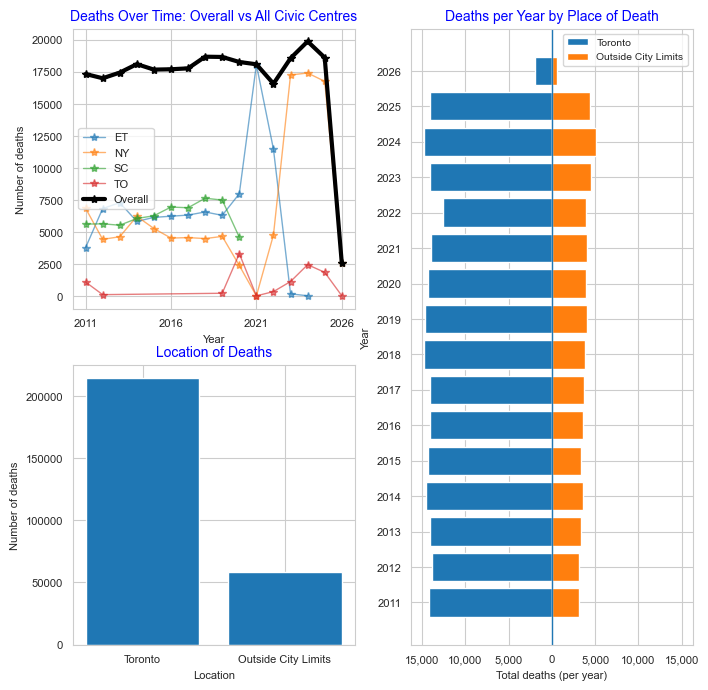

In [76]:
# loading data
death = pd.read_csv("~/Desktop/DSI/visualization/02_activities/assignments/Death-Registry-Statistics-Data.csv")


# creating a moasic of graphs
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                    ['ax2', 'ax3']],
                                    figsize=(8,8
                                    ))


# plot 1 -ax1

# extracting just the year from time period
death["YEAR"] = death["TIME_PERIOD"].astype(str).str[:4].astype(int)


# sorting the year values by just the year 
death = death.sort_values("YEAR")

# grouping the number of deaths per year 
death_by_year = (
    death.groupby("YEAR", as_index=False)["DEATH_LICENSES"]
         .sum())

# Overall deaths per year
overall = (death.groupby("YEAR", as_index=False)["DEATH_LICENSES"]
           .sum()
           .sort_values("YEAR"))

# group the total for each year by civic centre
by_centre = (death.groupby(["YEAR", "CIVIC_CENTRE"], as_index=False)["DEATH_LICENSES"]
             .sum()
             .sort_values("YEAR"))

for centre, df in by_centre.groupby("CIVIC_CENTRE"):
    someaxes['ax1'].plot(df["YEAR"], df["DEATH_LICENSES"], marker="*", linewidth=1, alpha=0.6, label=str(centre))
someaxes['ax1'].plot(overall["YEAR"], overall["DEATH_LICENSES"], linewidth=3, marker="*", label="Overall", color='black')


someaxes['ax1'].set_xlabel("Year", fontsize=8)
someaxes['ax1'].set_xticks(np.arange(df["YEAR"].min(), df["YEAR"].max() + 1, 5))
someaxes['ax1'].set_ylabel("Number of deaths", fontsize=8)
someaxes['ax1'].set_title("Deaths Over Time: Overall vs All Civic Centres", color='blue', fontsize=10)
someaxes['ax1'].legend( loc="center left", ncol=1, fontsize=8)
someaxes['ax1'].tick_params(axis="both", labelsize=8)
someaxes['ax1'].grid(True)  


#plot 2 - ax2

# creating totals of each 
place_totals = (
    death.groupby("PLACE_OF_DEATH", as_index=False)["DEATH_LICENSES"]
         .sum()
         .sort_values("DEATH_LICENSES", ascending=False)
)


someaxes['ax2'].bar(place_totals["PLACE_OF_DEATH"], place_totals["DEATH_LICENSES"])
someaxes['ax2'].set_xlabel("Location", fontsize=8)
someaxes['ax2'].set_ylabel("Number of deaths", fontsize=8)
someaxes['ax2'].set_title("Location of Deaths", color='blue', fontsize=10)
someaxes['ax2'].tick_params(axis="both", labelsize=8)


# graph number 3: ax3

# sorting the total number of deaths per year and by location
by_year_place = (
    death.groupby(["YEAR", "PLACE_OF_DEATH"], as_index=False)["DEATH_LICENSES"]
         .sum()
)

# determining the top places without hard coding
top_places = (
    by_year_place.groupby("PLACE_OF_DEATH")["DEATH_LICENSES"].sum()
    .sort_values(ascending=False)
    .head(2)
    .index
    .tolist()
)

place_left, place_right = top_places[0], top_places[1]

p = by_year_place.pivot(index="YEAR", columns="PLACE_OF_DEATH", values="DEATH_LICENSES").fillna(0)

# Keep only the two places we want
p = p[[place_left, place_right]].sort_index()

years = p.index.astype(int)
left_vals  = -p[place_left].values   # negative for left side
right_vals =  p[place_right].values  # positive for right side

someaxes['ax3'].barh(years, left_vals, label=place_left)
someaxes['ax3'].barh(years, right_vals, label=place_right)


# Make the x-axis show positive numbers on both sides
max_val = max(p[place_left].max(), p[place_right].max())
someaxes['ax3'].set_xlim(-max_val * 1.1, max_val * 1.1)
someaxes['ax3'].xaxis.set_major_formatter(lambda x, pos: f"{abs(int(x)):,}")

someaxes['ax3'].set_xlabel("Total deaths (per year)", fontsize=8)
someaxes['ax3'].set_ylabel("Year", fontsize=8)
someaxes['ax3'].set_yticks(p.index)
someaxes['ax3'].set_yticklabels(p.index.astype(int))
someaxes['ax3'].tick_params(axis="both", labelsize=8)
someaxes['ax3'].set_title("Deaths per Year by Place of Death", color='blue', fontsize=10)
someaxes['ax3'].axvline(0, linewidth=1)   # center line
someaxes['ax3'].legend(loc='upper right', ncol=1, fontsize=7.5)

Description of visualization:

This visualization was created using Python in a Jupyter Notebook environment, primarily with pandas for data cleaning/aggregation and Matplotlib (subplot mosaic) for plotting. My intended audience is city planners, public health officials, and policy analysts who need a quick, evidence-based view of mortality patterns across Toronto and surrounding areas.

The message I’m trying to convey is how recorded deaths change over time, and how location (Toronto vs outside city limits), and  civic centres relate to those changes. The line plot compares the overall yearly trend to trends by individual civic centres, while the bar chart summarizes deaths by place of death. The mirrored horizontal bars make it easy to compare Toronto vs outside city limits year-by-year.

Design choices focused on clarity and comparability. I used consistent axes and labeling (Year on the x-axis, deaths on the y-axis), a prominent overall line (black, thicker) to anchor interpretation, and lighter civic-centre lines so the overall trend remains readable. I also set ticks to show every 5 years to reduce clutter while keeping star markers for each year. 

To ensure reproducibility, I used scripted data transformation steps (extract year, groupby sums, pivot) rather than using hard code, so this we can use the same script to recreate the same data using the original CSV or using a new CSV (updated or unrelated having the same varaiables). Anyone with the same file and the notebook can re-run the analysis end-to-end and obtain the same outputs. If the tool were not reproducible, results would be harder to verify, update, or audit.

For accessibility, I included clear titles, axis labels, and legible font sizes, and used gridlines to support visual estimation. To further improve accessibility, I could add a colour-blind–safe palette and/or direct labels for key lines instead of a large legend, but in this case, I chose to use very minimal colours in my design. 

Individuals and communities impacted include Toronto residents, healthcare providers, and communities experiencing disproportionate mortality outcomes. This kind of visualization can inform resource allocation, emergency planning, and local health interventions.

The “Underwater labour” included modifying columns and extracting data by year and location to improve the comparability of these variables.